In [14]:
import sys, warnings
sys.path.append(r"C:\Projects\anomaly-detection-fundamentals\Modeling\Code")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import average_precision_score
from eval_protocol import time_split_per_kpi, evaluate_protocol
from preprocess import preprocess_all

In [15]:
KPI_PREFIX = "02e99bd4"
PERIOD = 1440              # chu kỳ ngày: 86400s / 60s = 1440 điểm
df = pd.read_csv(r"C:\Projects\anomaly-detection-fundamentals\Data\train.csv")
df.columns = ["timestamp", "value", "label", "kpi"]
kpi = [k for k in df.kpi.unique() if k.startswith(KPI_PREFIX)][0]

g = df[df.kpi == kpi].copy()
step = int(pd.Series(np.diff(np.sort(g.timestamp.values))).mode().iloc[0])
g = time_split_per_kpi(g, train_frac=0.6, val_frac=0.2)
p = preprocess_all(g, max_gap_points=5, norm_method="robust").sort_values("timestamp").reset_index(drop=True)

In [16]:
print("KPI:", kpi, "| tổng điểm:", len(p), "| step:", step, "s | PERIOD:", PERIOD)
for s in ["train", "val", "test"]:
    sub = p[p.split == s]
    print(f"  {s:5s}: {len(sub):6d} điểm | anomaly={int(sub.label.sum()):5d} ({sub.label.mean()*100:.2f}%)")

KPI: 02e99bd4f6cfb33f | tổng điểm: 131795 | step: 60 s | PERIOD: 1440
  train:  80169 điểm | anomaly= 8444 (10.53%)
  val  :  25718 điểm | anomaly=  724 (2.82%)
  test :  25908 điểm | anomaly= 1382 (5.33%)


In [17]:
MIN_LEN = 2 * PERIOD       # STL yêu cầu tối thiểu 2 chu kỳ đầy đủ
real = p[p.value_filled.notna()]
seg_len = real.groupby("segment").size().sort_values(ascending=False)
seg_ok = seg_len[seg_len >= MIN_LEN].index                 # segment đủ dài
p["stl_ok"] = p.segment.isin(seg_ok)                        # cờ: điểm này nằm trong segment STL được

print(f"MIN_LEN (2 chu kỳ) = {MIN_LEN}")
print(f"Tổng segment: {p.segment.nunique()} | đủ dài cho STL: {len(seg_ok)}")
print("\nTop segment (số điểm thật):")
print(seg_len.head(8).to_string())

cov = p[p.stl_ok & p.value_filled.notna()]
print(f"\nPhủ bởi segment đủ dài: {len(cov)}/{len(real)} điểm thật ({len(cov)/len(real)*100:.1f}%)")
for s in ["train", "val", "test"]:
    tot = (real.split == s).sum(); c = (cov.split == s).sum()
    print(f"  {s:5s}: {c}/{tot} điểm dùng được cho STL ({c/tot*100:.1f}%)")

MIN_LEN (2 chu kỳ) = 2880
Tổng segment: 23 | đủ dài cho STL: 12

Top segment (số điểm thật):
segment
18    56771
22    23959
4      6060
9      5160
5      4920
0      3600
16     3391
6      3281

Phủ bởi segment đủ dài: 119322/128599 điểm thật (92.8%)
  train: 69259/77162 điểm dùng được cho STL (89.8%)
  val  : 25718/25718 điểm dùng được cho STL (100.0%)
  test : 24345/25719 điểm dùng được cho STL (94.7%)


In [18]:
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import average_precision_score

# Chọn robust bằng AP trên VAL (không phải train)
seg_id = p[(p.split == "val") & p.value_filled.notna()].groupby("segment").size().idxmax()
segser = p[(p.segment == seg_id) & p.value_filled.notna()].sort_values("timestamp").reset_index(drop=True)

vpos = np.where(segser.split.values == "val")[0]; vlo, vhi = vpos.min(), vpos.max()
LEAD = 2 * PERIOD                                     # dẫn nhập để STL có bối cảnh
sl = segser.iloc[max(0, vlo - LEAD): vhi + 1].reset_index(drop=True)
is_val = sl.split.values == "val"; y_val = sl.label.values.astype(int)

for rob in [False, True]:
    r = STL(sl.value_norm.values, period=PERIOD, robust=rob).fit()
    ap = average_precision_score(y_val[is_val], np.abs(r.resid)[is_val])
    ratio = np.abs(r.resid[is_val][y_val[is_val]==1]).mean() / np.abs(r.resid[is_val][y_val[is_val]==0]).mean()
    print(f"robust={rob!s:5s}: AP_val={ap:.4f} | tách anomaly={ratio:.1f}x | seasonal std={r.seasonal.std():.3f}")

ROBUST = False
print(f"\n=> Dùng robust={ROBUST}")


robust=False: AP_val=0.2350 | tách anomaly=2.6x | seasonal std=0.880
robust=True : AP_val=0.2365 | tách anomaly=3.4x | seasonal std=0.883

=> Dùng robust=False


In [19]:
import time

MIN_LEN = 2 * PERIOD
seg_ok = seg_len[seg_len >= MIN_LEN].index

p["stl_resid"] = np.nan; p["stl_trend"] = np.nan; p["stl_seasonal"] = np.nan
t0 = time.time()
for sid in seg_ok:
    idx = p.index[(p.segment == sid) & p.value_filled.notna()]
    r = STL(p.loc[idx, "value_norm"].values, period=PERIOD, robust=ROBUST).fit()
    p.loc[idx, "stl_resid"]    = r.resid
    p.loc[idx, "stl_trend"]    = r.trend
    p.loc[idx, "stl_seasonal"] = r.seasonal
print(f"phân rã {len(seg_ok)} segment trong {time.time()-t0:.0f}s")

got = p.stl_resid.notna()
print("điểm có residual:", int(got.sum()), "/", len(p))
for s in ["val", "test"]:
    m = (p.split == s); print(f"  {s}: {int((got & m).sum())}/{int(m.sum())} có residual")


phân rã 12 segment trong 151s
điểm có residual: 119322 / 131795
  val: 25718/25718 có residual
  test: 24345/25908 có residual


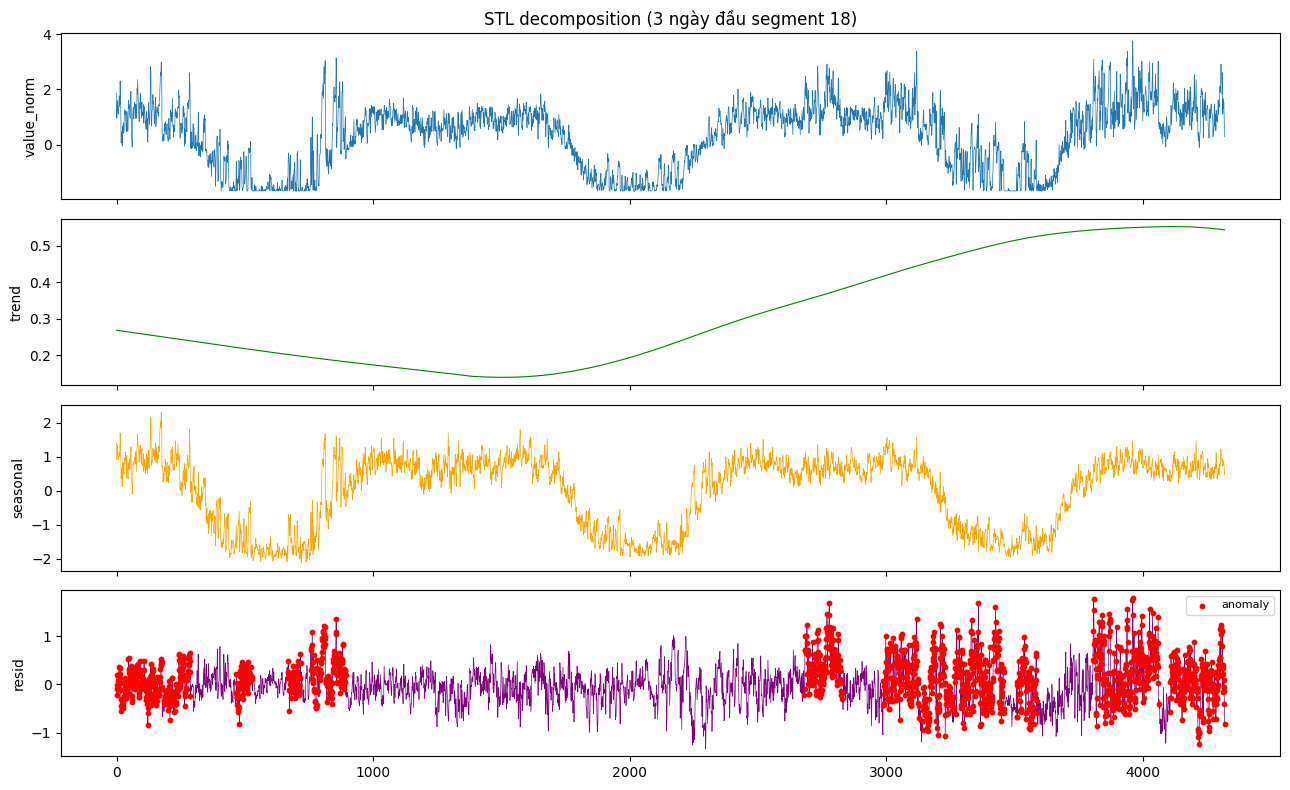

In [20]:
sid = seg_len.idxmax()
seg = p[(p.segment == sid) & p.stl_resid.notna()].head(3 * PERIOD).reset_index(drop=True)
fig, ax = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
ax[0].plot(seg.value_norm.values, lw=.5);                  ax[0].set_ylabel("value_norm")
ax[1].plot(seg.stl_trend.values, lw=.8, color="green");    ax[1].set_ylabel("trend")
ax[2].plot(seg.stl_seasonal.values, lw=.5, color="orange");ax[2].set_ylabel("seasonal")
ax[3].plot(seg.stl_resid.values, lw=.5, color="purple");   ax[3].set_ylabel("resid")
an = seg.label.values == 1
ax[3].scatter(np.where(an)[0], seg.stl_resid.values[an], color="red", s=10, zorder=5, label="anomaly")
ax[3].legend(fontsize=8); ax[0].set_title(f"STL decomposition (3 ngày đầu segment {sid})")
plt.tight_layout(); plt.show()

In [21]:
# center/scale robust từ residual TRAIN
rtr = p.loc[(p.split == "train") & p.stl_resid.notna(), "stl_resid"]
med = rtr.median()
mad = np.median(np.abs(rtr - med)) * 1.4826
p["score"] = np.abs(p.stl_resid - med) / mad
print(f"median residual (train) = {med:.4f} | MAD×1.4826 = {mad:.4f}\n")

for s in ["train", "val", "test"]:
    m = (p.split == s) & p.stl_resid.notna()
    sc, y = p.loc[m, "score"], p.loc[m, "label"].values
    print(f"{s:5s}: score bình thường(median)={np.median(sc[y==0]):.2f} | anomaly(median)={np.median(sc[y==1]):.2f} "
          f"| %score>3: anomaly={np.mean(sc[y==1]>3)*100:.0f}% bình thường={np.mean(sc[y==0]>3)*100:.1f}%")


median residual (train) = 0.0000 | MAD×1.4826 = 0.1261

train: score bình thường(median)=0.59 | anomaly(median)=2.13 | %score>3: anomaly=39% bình thường=7.0%
val  : score bình thường(median)=1.18 | anomaly(median)=1.82 | %score>3: anomaly=35% bình thường=10.9%
test : score bình thường(median)=1.45 | anomaly(median)=5.94 | %score>3: anomaly=68% bình thường=20.7%


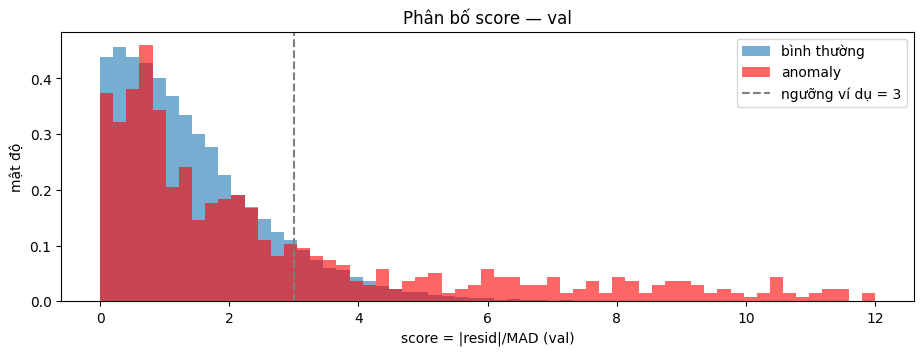

In [22]:
m = (p.split == "val") & p.stl_resid.notna()
sc, y = p.loc[m, "score"].values, p.loc[m, "label"].values
plt.figure(figsize=(11, 3.5))
bins = np.linspace(0, 12, 60)
plt.hist(sc[y==0], bins=bins, alpha=.6, label="bình thường", density=True)
plt.hist(sc[y==1], bins=bins, alpha=.6, label="anomaly", density=True, color="red")
plt.axvline(3, ls="--", color="grey", label="ngưỡng ví dụ = 3")
plt.xlabel("score = |resid|/MAD (val)"); plt.ylabel("mật độ"); plt.legend(); plt.title("Phân bố score — val"); plt.show()


In [23]:
from eval_protocol import evaluate_protocol

y = p.label.values.astype(int)
ok = p.stl_resid.notna().values
vm = (p.split == "val").values  & ok
tm = (p.split == "test").values & ok
r = evaluate_protocol(y[vm], p.score.values[vm], y[tm], p.score.values[tm], beta=1.0, step_s=step)

print(f"=== STL + residual thresholding | KPI {kpi[:8]} ===")
print(f"  valid: val={vm.sum()} test={tm.sum()}")
print(f"  AP_test = {r['AP_pw']:.3f}")
print(f"  PW : P={r['PW']['precision']:.3f} R={r['PW']['recall']:.3f} F1={r['PW']['fbeta']:.3f}")
print(f"  PA : P={r['PA']['precision']:.3f} R={r['PA']['recall']:.3f} F1={r['PA']['fbeta']:.3f}")
print(f"  TTD: {r['TTD']}")

=== STL + residual thresholding | KPI 02e99bd4 ===
  valid: val=25718 test=24345
  AP_test = 0.468
  PW : P=0.381 R=0.506 F1=0.435
  PA : P=0.707 R=1.000 F1=0.828
  TTD: {'ttd_sec_mean': 37.5, 'detected_segments': 8, 'total_segments': 8}


In [24]:
compare = pd.DataFrame([
    dict(model="IsolationForest (feature)", AP=0.885, PW_F1=0.754, PA_F1=0.978, TTD_s=None),
    dict(model="IsolationForest (shingle)", AP=0.796, PW_F1=0.674, PA_F1=0.815, TTD_s=None),
    dict(model="ARIMA(2,0,0)",              AP=0.481, PW_F1=0.486, PA_F1=0.973, TTD_s=100.0),
    dict(model="STL + resid threshold",     AP=round(r['AP_pw'],3), PW_F1=round(r['PW']['fbeta'],3),
         PA_F1=round(r['PA']['fbeta'],3), TTD_s=r['TTD']['ttd_sec_mean']),
]).sort_values("AP", ascending=False)
print(compare.to_string(index=False))

                    model    AP  PW_F1  PA_F1  TTD_s
IsolationForest (feature) 0.885  0.754  0.978    NaN
IsolationForest (shingle) 0.796  0.674  0.815    NaN
             ARIMA(2,0,0) 0.481  0.486  0.973  100.0
    STL + resid threshold 0.468  0.435  0.828   37.5
